Multivariate Linear Regression

Goal:

Understand how Multivariate linear regression works using Scikit-learn.

Dataset:

A small dataset containing employee's experience,scores and salary

Steps:

Import libraries
Load dataset
Clean dataset(Handle missing values,Changing test data to numerical to get better result with linear regression)
Train Linear Regression model
Predict values
Visualize results

In [2]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("hiring.csv")

In [4]:
df.experience=df.experience.fillna("zero")

In [6]:
df.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,zero,8.0,9,50000
1,zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


In [8]:
test_score_median=df['test_score(out of 10)'].median()

In [10]:
df['test_score(out of 10)']=df['test_score(out of 10)'].fillna(test_score_median)
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,zero,8.0,9,50000
1,zero,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000
5,three,7.0,10,62000
6,ten,8.0,7,72000
7,eleven,7.0,8,80000


In [11]:
!pip install word2number

  Preparing metadata (setup.py) ... done
  Created wheel for word2number: filename=word2number-1.1-py3-none-any.whl size=5568 sha256=b4e2b95f60ddd9c553ac48c47284652983764c282253aa411dcae56ab6f7c62a
  Stored in directory: /root/.cache/pip/wheels/5b/79/fb/d25928e599c7e11fe4e00d32048cd74933f34a74c633d2aea6
Successfully built word2number


In [15]:
from word2number import w2n
df['marks'] = df['marks'].apply(w2n.word_to_num)

In [17]:
df

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0,8.0,9,50000
1,0,8.0,6,45000
2,5,6.0,7,60000
3,2,10.0,10,65000
4,7,9.0,6,70000
5,3,7.0,10,62000
6,10,8.0,7,72000
7,11,7.0,8,80000


In [19]:
reg=linear_model.LinearRegression()
reg.fit(df[['experience','test_score(out of 10)','interview_score(out of 10)']],df['salary($)'])

LinearRegression()

In [21]:
print(reg.coef_)
print(reg.intercept_)

[2812.95487627 1845.70596798 2205.24017467]
17737.263464337688


In [22]:
reg.predict([[3,7,9]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([58943.23144105])

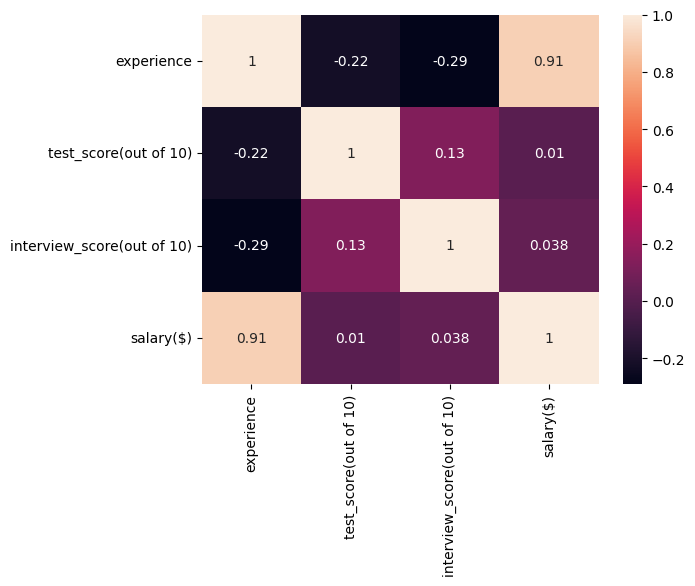

In [23]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)
plt.show()